# Лабораторна 3: Базова CNN модель для CIFAR-10 (PyTorch)

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os
from sklearn.metrics import f1_score
import datetime
from torchsummary import summary
import random


In [3]:
print(torch.cuda.is_available())  

True


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # перетворює зображення у тензор [0, 1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1, 1]
]) 

# Датасети
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

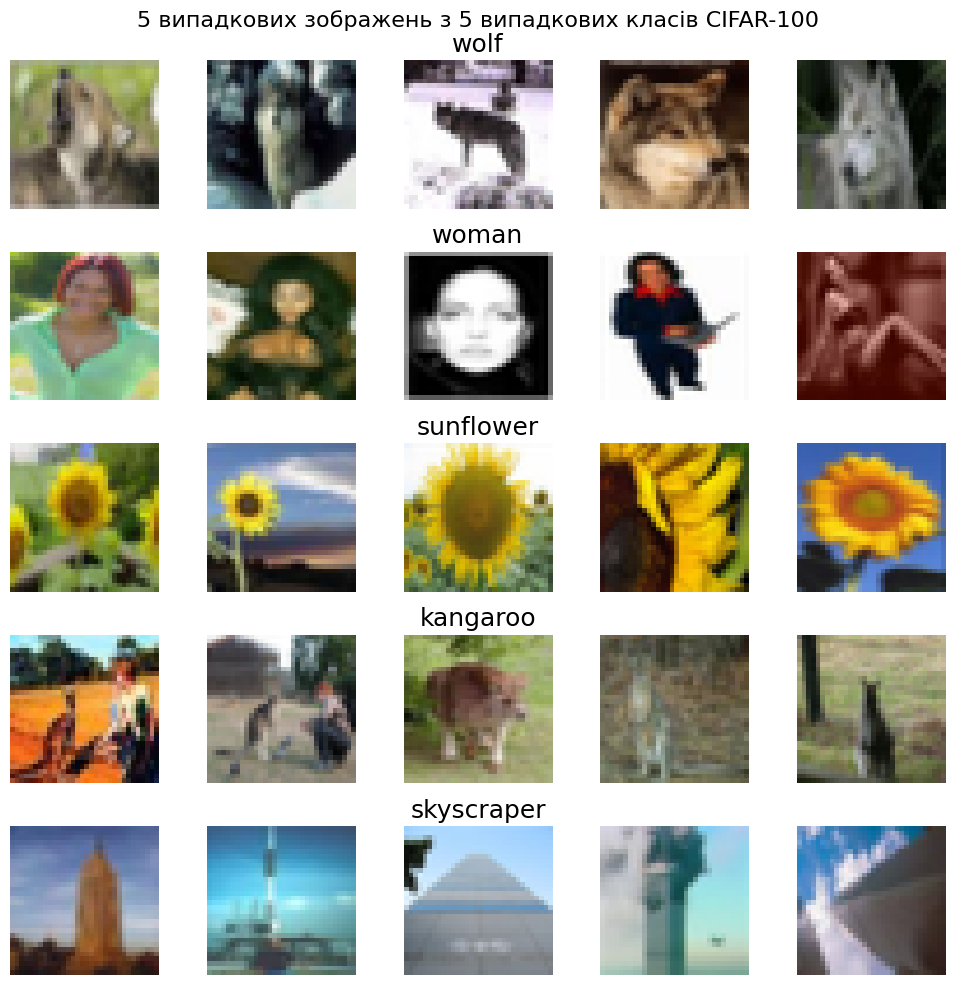

In [5]:
class_names = trainset.classes
print(class_names)
random_classes = random.sample(class_names, 5)
class_indices = {cls: [] for cls in random_classes}

for img, label in trainset:
    name = class_names[label]
    if name in random_classes and len(class_indices[name]) < 5:
        class_indices[name].append(img)
    if all(len(v) == 5 for v in class_indices.values()):
        break


fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle('5 випадкових зображень з 5 випадкових класів CIFAR-100', fontsize=16)

for row, (cls, images) in enumerate(class_indices.items()):
    for col, img in enumerate(images):
        img = img.numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 2:
            axes[row, col].set_title(cls, fontsize=18, loc='center')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [23]:
def top_k_accuracy(output, target, k=2):
    _, pred = output.topk(k, dim=1)
    correct = pred.eq(target.view(-1, 1).expand_as(pred))
    return correct.sum().item() / target.size(0)

## Функції навчання

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_one_epoch(model, trainloader, optimizer, criterion, device, top_k_accuracy):
    model.train()
    running_loss, running_acc, running_top2 = 0.0, 0.0, 0.0
    all_preds = [] # Усі передбачені мітки (для F1)
    all_labels = [] # Усі істинні мітки

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad() # Обнуляємо попередні градієнти

        outputs = model(inputs) # Прямий прохід
        loss = criterion(outputs, labels) # Обчислюємо втрати
        loss.backward() # Зворотне поширення (обчислення градієнтів)
        optimizer.step() # Оновлюємо ваги моделі

        running_loss += loss.item()
        _, preds = outputs.max(1)
        running_acc += (preds == labels).sum().item() / labels.size(0)
        running_top2 += top_k_accuracy(outputs, labels, k=2)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro') 
    return running_loss / len(trainloader), running_acc / len(trainloader), running_top2 / len(trainloader), f1

def validate(model, testloader, criterion, device, top_k_accuracy):
    model.eval()  # Переводимо модель у режим оцінки (виключає dropout, batchnorm)
    val_loss, val_acc, val_top2 = 0.0, 0.0, 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Вимикаємо обчислення градієнтів (для швидкості та економії пам’яті)
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_acc += (preds == labels).sum().item() / labels.size(0)
            val_top2 += top_k_accuracy(outputs, labels, k=2)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='macro') 
    return val_loss / len(testloader), val_acc / len(testloader), val_top2 / len(testloader), f1


In [ ]:
def train_and_evaluate_model(
    model,
    trainloader,
    testloader,
    device,
    top_k_accuracy,
    num_epochs=10,
    lr=0.001,
    model_name="UnnamedModel",
    csv_path="results.csv",
    patience=3,
    save_best=True
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    results = []
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        start_time = time.time()

        epoch_loss, epoch_acc, epoch_top2, epoch_f1 = train_one_epoch(
            model, trainloader, optimizer, criterion, device, top_k_accuracy
        )

        val_loss, val_acc, val_top2, val_f1 = validate(
            model, testloader, criterion, device, top_k_accuracy
        )

        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1} /// acc: {epoch_acc:.4f} /// f1: {epoch_f1:.4f} /// loss: {epoch_loss:.4f} /// "
              f"val_acc: {val_acc:.4f} /// val_f1: {val_f1:.4f} /// val_loss: {val_loss:.4f} /// time: {epoch_time:.2f}s")

        results.append({
            "epoch": epoch + 1,
            "model": model_name,
            "train_accuracy": epoch_acc,
            "train_loss": epoch_loss,
            "train_top2": epoch_top2,
            "train_f1": epoch_f1,
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "val_top2": val_top2,
            "val_f1": val_f1,
            "epoch_time_sec": epoch_time
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            if save_best:
                best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
    # === Saving stats (accuracy, time...) in DataFrame ===
    if csv_path:
        df_results = pd.DataFrame(results)
        if os.path.exists(csv_path):
            df_existing = pd.read_csv(csv_path)
            df_results = pd.concat([df_existing, df_results], ignore_index=True)
        df_results.to_csv(csv_path, index=False)

    # === Saving weights of model ===
    timestamp = datetime.datetime.now().strftime("%d%m%Y_%S%M%H")
    filename = f"models/{model_name}_{timestamp}"
    if save_best and best_model_state is not None:
        torch.save(best_model_state, f"{filename}_best.pt")
        print(f"Найкраща модель збережена як {filename}_best.pt")
    else:
        torch.save(model.state_dict(), f"{filename}.pt")
        print(f"Модель збережена як {filename}.pt")

    return df_results, model

## Моделі

### Базова модель

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 100)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
model = BaselineCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
         MaxPool2d-2           [-1, 32, 16, 16]               0
            Conv2d-3           [-1, 64, 16, 16]          18,496
         MaxPool2d-4             [-1, 64, 8, 8]               0
            Linear-5                  [-1, 128]         524,416
            Linear-6                  [-1, 100]          12,900
Total params: 556,708
Trainable params: 556,708
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.47
Params size (MB): 2.12
Estimated Total Size (MB): 2.61
----------------------------------------------------------------


### Модель з трьома conv шарами

In [ ]:
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32->16
        x = self.pool(F.relu(self.conv2(x)))   # 16->8
        x = self.pool(F.relu(self.conv3(x)))   # 8->4
        x = x.view(-1, 128 * 4 * 4) 
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [9]:
model = DeeperCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 128, 8, 8]         147,584
         MaxPool2d-6            [-1, 128, 4, 4]               0
            Linear-7                  [-1, 256]         524,544
            Linear-8                  [-1, 100]          25,700
Total params: 773,476
Trainable params: 773,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.02
Params size (MB): 2.95
Estimated Total Size (MB): 3.98
----------------------------------------------------------------


### Модель з dropout

In [ ]:
class DeeperDropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)
        self.dropout1 = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32->16
        x = self.pool(F.relu(self.conv2(x)))   # 16->8
        x = self.pool(F.relu(self.conv3(x)))   # 8->4
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        return self.fc2(x)

In [11]:
model = DeeperDropoutCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 128, 8, 8]         147,584
         MaxPool2d-6            [-1, 128, 4, 4]               0
            Linear-7                  [-1, 256]         524,544
           Dropout-8                  [-1, 256]               0
            Linear-9                  [-1, 100]          25,700
Total params: 773,476
Trainable params: 773,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.02
Params size (MB): 2.95
Estimated Total Size (MB): 3.98
-------------------------------------------

### Модель з двома dropout

In [ ]:
class DeeperDropout2CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout2d(p=0.3)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)
        self.dropout_fc = nn.Dropout(p=0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32->16
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv2(x)))   # 16->8
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.conv3(x)))   # 8->4
        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        return self.fc2(x)

In [13]:
model = DeeperDropout2CNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
         Dropout2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
         MaxPool2d-5            [-1, 128, 8, 8]               0
         Dropout2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]         147,584
         MaxPool2d-8            [-1, 128, 4, 4]               0
            Linear-9                  [-1, 256]         524,544
          Dropout-10                  [-1, 256]               0
           Linear-11                  [-1, 100]          25,700
Total params: 773,476
Trainable params: 773,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/

### Модель з LeakyRelu

In [ ]:
class LeakyReluCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x), negative_slope=0.1))   # 32->16
        x = self.pool(F.leaky_relu(self.conv2(x), negative_slope=0.1))   # 16->8
        x = self.pool(F.leaky_relu(self.conv3(x), negative_slope=0.1))   # 8->4
        x = x.view(-1, 128 * 4 * 4)
        x = F.leaky_relu(self.fc1(x))
        return self.fc2(x)

In [15]:
model = LeakyReluCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 128, 8, 8]         147,584
         MaxPool2d-6            [-1, 128, 4, 4]               0
            Linear-7                  [-1, 256]         524,544
            Linear-8                  [-1, 100]          25,700
Total params: 773,476
Trainable params: 773,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.02
Params size (MB): 2.95
Estimated Total Size (MB): 3.98
----------------------------------------------------------------


### Модель з LeakyRelu + dropout

In [ ]:
class LeakyReluDropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 100)
        self.dropout_conv = nn.Dropout2d(p=0.3)
        self.dropout_fc = nn.Dropout(p=0.4)

    def forward(self, x):
        x = self.pool(F.leaky_relu(self.conv1(x), negative_slope=0.1))   # 32->16
        x = self.dropout_conv(x)
        x = self.pool(F.leaky_relu(self.conv2(x), negative_slope=0.1))   # 16->8
        x = self.dropout_conv(x)
        x = self.pool(F.leaky_relu(self.conv3(x), negative_slope=0.1))   # 8->4
        x = x.view(-1, 128 * 4 * 4)
        x = F.leaky_relu(self.fc1(x))
        x = self.dropout_fc(x)
        return self.fc2(x)
    

In [17]:
model = LeakyReluCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
         MaxPool2d-2           [-1, 64, 16, 16]               0
            Conv2d-3          [-1, 128, 16, 16]          73,856
         MaxPool2d-4            [-1, 128, 8, 8]               0
            Conv2d-5            [-1, 128, 8, 8]         147,584
         MaxPool2d-6            [-1, 128, 4, 4]               0
            Linear-7                  [-1, 256]         524,544
            Linear-8                  [-1, 100]          25,700
Total params: 773,476
Trainable params: 773,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.02
Params size (MB): 2.95
Estimated Total Size (MB): 3.98
----------------------------------------------------------------


### Модель з batch normalization + dropout

In [18]:
class DeeperBatchNormCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 32→16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 16→8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 8→4

        x = x.view(-1, 128 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [19]:
model = DeeperBatchNormCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
       BatchNorm2d-5          [-1, 128, 16, 16]             256
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]         147,584
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
          Dropout-11                  [-1, 256]               0
           Linear-12                  [-1, 100]          25,700
Total params: 774,116
Trainable params: 774,116
Non-trainable params: 0
-------------------------------

### Модель "складна"

In [20]:
class tralalaCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Блок 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)  # 32 -> 16
        self.drop1 = nn.Dropout2d(p=0.2)

        # Блок 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)  # 16 -> 8
        self.drop2 = nn.Dropout2d(p=0.3)

        # Блок 3
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)  # 8 -> 4
        self.drop3 = nn.Dropout2d(p=0.4)

        # Класифікатор
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))
        x = self.drop1(x)

        x = self.pool2(F.relu(self.bn4(self.conv4(F.relu(self.bn3(self.conv3(x)))))))
        x = self.drop2(x)

        x = self.pool3(F.relu(self.bn5(self.conv5(x))))
        x = self.drop3(x)

        x = x.view(-1, 256 * 4 * 4)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        return self.fc2(x)

In [21]:
model = tralalaCNN().to("cuda")
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,928
       BatchNorm2d-4           [-1, 64, 32, 32]             128
         MaxPool2d-5           [-1, 64, 16, 16]               0
         Dropout2d-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
       BatchNorm2d-8          [-1, 128, 16, 16]             256
            Conv2d-9          [-1, 128, 16, 16]         147,584
      BatchNorm2d-10          [-1, 128, 16, 16]             256
        MaxPool2d-11            [-1, 128, 8, 8]               0
        Dropout2d-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         295,168
      BatchNorm2d-14            [-1, 25

## Навчання моделей

### Базова модель

In [27]:
df1, trained_model_baseline = train_and_evaluate_model(
    model = BaselineCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=30,
    lr=0.001,
    model_name="BaselineCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.1677 /// f1: 0.1516 /// loss: 3.5402 /// val_acc: 0.2526 /// val_f1: 0.2319 /// val_loss: 3.0703 /// time: 22.81s
Epoch 2 /// acc: 0.2975 /// f1: 0.2840 /// loss: 2.8167 /// val_acc: 0.3183 /// val_f1: 0.3111 /// val_loss: 2.7398 /// time: 22.51s
Epoch 3 /// acc: 0.3648 /// f1: 0.3547 /// loss: 2.4901 /// val_acc: 0.3547 /// val_f1: 0.3445 /// val_loss: 2.5628 /// time: 20.56s
Epoch 4 /// acc: 0.4133 /// f1: 0.4054 /// loss: 2.2518 /// val_acc: 0.3739 /// val_f1: 0.3678 /// val_loss: 2.4918 /// time: 21.24s
Epoch 5 /// acc: 0.4574 /// f1: 0.4506 /// loss: 2.0619 /// val_acc: 0.3895 /// val_f1: 0.3828 /// val_loss: 2.4226 /// time: 21.67s
Epoch 6 /// acc: 0.4944 /// f1: 0.4884 /// loss: 1.8995 /// val_acc: 0.4023 /// val_f1: 0.3956 /// val_loss: 2.3785 /// time: 21.51s
Epoch 7 /// acc: 0.5288 /// f1: 0.5237 /// loss: 1.7488 /// val_acc: 0.3971 /// val_f1: 0.3916 /// val_loss: 2.4427 /// time: 21.54s
Epoch 8 /// acc: 0.5549 /// f1: 0.5503 /// loss: 1.6204 /// val_acc: 

### Модель з трьома conv шарами

In [28]:
df2, trained_model_deeper = train_and_evaluate_model(
    model = DeeperCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=30,
    lr=0.001,
    model_name="DeeperCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.1420 /// f1: 0.1264 /// loss: 3.6556 /// val_acc: 0.2295 /// val_f1: 0.2071 /// val_loss: 3.1459 /// time: 23.68s
Epoch 2 /// acc: 0.2881 /// f1: 0.2755 /// loss: 2.8402 /// val_acc: 0.3251 /// val_f1: 0.3029 /// val_loss: 2.6830 /// time: 23.65s
Epoch 3 /// acc: 0.3655 /// f1: 0.3561 /// loss: 2.4561 /// val_acc: 0.3699 /// val_f1: 0.3600 /// val_loss: 2.4694 /// time: 23.62s
Epoch 4 /// acc: 0.4198 /// f1: 0.4124 /// loss: 2.2037 /// val_acc: 0.3914 /// val_f1: 0.3824 /// val_loss: 2.3668 /// time: 24.49s
Epoch 5 /// acc: 0.4652 /// f1: 0.4596 /// loss: 1.9981 /// val_acc: 0.4094 /// val_f1: 0.4021 /// val_loss: 2.2944 /// time: 23.66s
Epoch 6 /// acc: 0.5020 /// f1: 0.4968 /// loss: 1.8339 /// val_acc: 0.4152 /// val_f1: 0.4071 /// val_loss: 2.2809 /// time: 24.27s
Epoch 7 /// acc: 0.5346 /// f1: 0.5299 /// loss: 1.6949 /// val_acc: 0.4206 /// val_f1: 0.4169 /// val_loss: 2.3171 /// time: 23.69s
Epoch 8 /// acc: 0.5639 /// f1: 0.5602 /// loss: 1.5645 /// val_acc: 

### Модель з dropout

In [34]:
df3, trained_model_deeperdropout = train_and_evaluate_model(
    model = DeeperDropoutCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=30,
    lr=0.001,
    model_name="DeeperDropoutCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.0871 /// f1: 0.0731 /// loss: 3.9722 /// val_acc: 0.1868 /// val_f1: 0.1557 /// val_loss: 3.4163 /// time: 24.84s
Epoch 2 /// acc: 0.1852 /// f1: 0.1683 /// loss: 3.3715 /// val_acc: 0.2643 /// val_f1: 0.2474 /// val_loss: 3.0020 /// time: 23.81s
Epoch 3 /// acc: 0.2395 /// f1: 0.2236 /// loss: 3.0616 /// val_acc: 0.2977 /// val_f1: 0.2814 /// val_loss: 2.7898 /// time: 26.31s
Epoch 4 /// acc: 0.2752 /// f1: 0.2613 /// loss: 2.8715 /// val_acc: 0.3420 /// val_f1: 0.3255 /// val_loss: 2.5949 /// time: 26.36s
Epoch 5 /// acc: 0.3055 /// f1: 0.2915 /// loss: 2.7181 /// val_acc: 0.3665 /// val_f1: 0.3501 /// val_loss: 2.4818 /// time: 25.06s
Epoch 6 /// acc: 0.3267 /// f1: 0.3143 /// loss: 2.6048 /// val_acc: 0.3812 /// val_f1: 0.3657 /// val_loss: 2.4151 /// time: 25.06s
Epoch 7 /// acc: 0.3513 /// f1: 0.3388 /// loss: 2.4987 /// val_acc: 0.3850 /// val_f1: 0.3689 /// val_loss: 2.3716 /// time: 26.47s
Epoch 8 /// acc: 0.3691 /// f1: 0.3577 /// loss: 2.3982 /// val_acc: 

### Модель з двома dropout

In [15]:
df4, trained_model_deeperdropout2 = train_and_evaluate_model(
    model = DeeperDropout2CNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=100,
    lr=0.001,
    model_name="DeeperDropout2CNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.0759 /// f1: 0.0620 /// loss: 4.0757 /// val_acc: 0.1573 /// val_f1: 0.1285 /// val_loss: 3.5767 /// time: 31.15s
Epoch 2 /// acc: 0.1522 /// f1: 0.1355 /// loss: 3.5794 /// val_acc: 0.2200 /// val_f1: 0.1952 /// val_loss: 3.2421 /// time: 23.88s
Epoch 3 /// acc: 0.1901 /// f1: 0.1737 /// loss: 3.3402 /// val_acc: 0.2694 /// val_f1: 0.2522 /// val_loss: 3.0189 /// time: 23.86s
Epoch 4 /// acc: 0.2208 /// f1: 0.2056 /// loss: 3.1888 /// val_acc: 0.2900 /// val_f1: 0.2734 /// val_loss: 2.8495 /// time: 24.03s
Epoch 5 /// acc: 0.2411 /// f1: 0.2264 /// loss: 3.0710 /// val_acc: 0.3175 /// val_f1: 0.3002 /// val_loss: 2.7953 /// time: 24.07s
Epoch 6 /// acc: 0.2585 /// f1: 0.2435 /// loss: 2.9847 /// val_acc: 0.3249 /// val_f1: 0.3093 /// val_loss: 2.7307 /// time: 24.26s
Epoch 7 /// acc: 0.2716 /// f1: 0.2569 /// loss: 2.9085 /// val_acc: 0.3395 /// val_f1: 0.3287 /// val_loss: 2.6269 /// time: 24.57s
Epoch 8 /// acc: 0.2866 /// f1: 0.2726 /// loss: 2.8408 /// val_acc: 

### Модель з LeakyRelu

In [16]:
df5, trained_model_LeakyReluCNN = train_and_evaluate_model(
    model = LeakyReluCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=100,
    lr=0.001,
    model_name="LeakyReluCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True)

Epoch 1 /// acc: 0.1888 /// f1: 0.1755 /// loss: 3.4123 /// val_acc: 0.3062 /// val_f1: 0.2883 /// val_loss: 2.7880 /// time: 23.32s
Epoch 2 /// acc: 0.3640 /// f1: 0.3547 /// loss: 2.4841 /// val_acc: 0.3836 /// val_f1: 0.3741 /// val_loss: 2.4355 /// time: 23.21s
Epoch 3 /// acc: 0.4680 /// f1: 0.4624 /// loss: 2.0023 /// val_acc: 0.4294 /// val_f1: 0.4227 /// val_loss: 2.1935 /// time: 23.09s
Epoch 4 /// acc: 0.5550 /// f1: 0.5510 /// loss: 1.6223 /// val_acc: 0.4548 /// val_f1: 0.4532 /// val_loss: 2.1469 /// time: 23.18s
Epoch 5 /// acc: 0.6372 /// f1: 0.6350 /// loss: 1.2718 /// val_acc: 0.4549 /// val_f1: 0.4487 /// val_loss: 2.2590 /// time: 23.61s
Epoch 6 /// acc: 0.7218 /// f1: 0.7205 /// loss: 0.9517 /// val_acc: 0.4459 /// val_f1: 0.4457 /// val_loss: 2.4925 /// time: 23.11s
Epoch 7 /// acc: 0.7940 /// f1: 0.7934 /// loss: 0.6811 /// val_acc: 0.4434 /// val_f1: 0.4408 /// val_loss: 2.8259 /// time: 23.10s
🛑 Early stopping triggered at epoch 7
💾 Найкраща модель збережена як 

### Модель з LeakyRelu + dropout

In [33]:
df6, trained_model_LeakyReluDropoutCNN = train_and_evaluate_model(
    model = LeakyReluDropoutCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=100,
    lr=0.001,
    model_name="LeakyReluDropoutCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True)

Epoch 1 /// acc: 0.1145 /// f1: 0.1018 /// loss: 3.8287 /// val_acc: 0.2434 /// val_f1: 0.2245 /// val_loss: 3.1533 /// time: 25.12s
Epoch 2 /// acc: 0.2285 /// f1: 0.2154 /// loss: 3.1536 /// val_acc: 0.3195 /// val_f1: 0.3032 /// val_loss: 2.7363 /// time: 26.02s
Epoch 3 /// acc: 0.2912 /// f1: 0.2797 /// loss: 2.8358 /// val_acc: 0.3717 /// val_f1: 0.3601 /// val_loss: 2.4902 /// time: 24.99s
Epoch 4 /// acc: 0.3377 /// f1: 0.3281 /// loss: 2.6033 /// val_acc: 0.3970 /// val_f1: 0.3879 /// val_loss: 2.3432 /// time: 24.51s
Epoch 5 /// acc: 0.3644 /// f1: 0.3557 /// loss: 2.4488 /// val_acc: 0.4127 /// val_f1: 0.4031 /// val_loss: 2.2547 /// time: 24.73s
Epoch 6 /// acc: 0.3960 /// f1: 0.3881 /// loss: 2.2993 /// val_acc: 0.4308 /// val_f1: 0.4236 /// val_loss: 2.1843 /// time: 25.28s
Epoch 7 /// acc: 0.4179 /// f1: 0.4103 /// loss: 2.1957 /// val_acc: 0.4391 /// val_f1: 0.4314 /// val_loss: 2.1509 /// time: 25.43s
Epoch 8 /// acc: 0.4383 /// f1: 0.4321 /// loss: 2.0972 /// val_acc: 

### Модель з batch normalization + dropout

In [34]:
df7, trained_model_DeeperBatchNormCNN = train_and_evaluate_model(
    model = DeeperBatchNormCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=100,
    lr=0.001,
    model_name="DeeperBatchNormCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.0852 /// f1: 0.0726 /// loss: 3.9580 /// val_acc: 0.1931 /// val_f1: 0.1663 /// val_loss: 3.3502 /// time: 31.17s
Epoch 2 /// acc: 0.1540 /// f1: 0.1369 /// loss: 3.4559 /// val_acc: 0.2537 /// val_f1: 0.2325 /// val_loss: 2.9822 /// time: 27.72s
Epoch 3 /// acc: 0.1905 /// f1: 0.1733 /// loss: 3.2213 /// val_acc: 0.3048 /// val_f1: 0.2844 /// val_loss: 2.7422 /// time: 26.59s
Epoch 4 /// acc: 0.2163 /// f1: 0.1994 /// loss: 3.0690 /// val_acc: 0.3265 /// val_f1: 0.3016 /// val_loss: 2.6105 /// time: 26.19s
Epoch 5 /// acc: 0.2414 /// f1: 0.2240 /// loss: 2.9478 /// val_acc: 0.3505 /// val_f1: 0.3294 /// val_loss: 2.5196 /// time: 33.29s
Epoch 6 /// acc: 0.2608 /// f1: 0.2435 /// loss: 2.8389 /// val_acc: 0.3604 /// val_f1: 0.3418 /// val_loss: 2.4687 /// time: 33.44s
Epoch 7 /// acc: 0.2748 /// f1: 0.2578 /// loss: 2.7467 /// val_acc: 0.3874 /// val_f1: 0.3718 /// val_loss: 2.3644 /// time: 28.71s
Epoch 8 /// acc: 0.2918 /// f1: 0.2756 /// loss: 2.6669 /// val_acc: 

### Модель "складна"

In [37]:
df7, trained_model_tralalaCNN = train_and_evaluate_model(
    model = tralalaCNN(),
    trainloader=trainloader,
    testloader=testloader,
    device=device,
    top_k_accuracy=top_k_accuracy,
    num_epochs=100,
    lr=0.001,
    model_name="tralalaCNN",
    csv_path="results.csv",
    patience=3,
    save_best=True
)

Epoch 1 /// acc: 0.1356 /// f1: 0.1238 /// loss: 3.6955 /// val_acc: 0.2800 /// val_f1: 0.2501 /// val_loss: 2.9366 /// time: 47.72s
Epoch 2 /// acc: 0.2437 /// f1: 0.2306 /// loss: 3.0571 /// val_acc: 0.3500 /// val_f1: 0.3251 /// val_loss: 2.5668 /// time: 47.16s
Epoch 3 /// acc: 0.3025 /// f1: 0.2909 /// loss: 2.7440 /// val_acc: 0.4060 /// val_f1: 0.3919 /// val_loss: 2.2690 /// time: 44.93s
Epoch 4 /// acc: 0.3456 /// f1: 0.3353 /// loss: 2.5327 /// val_acc: 0.4407 /// val_f1: 0.4283 /// val_loss: 2.1076 /// time: 48.43s
Epoch 5 /// acc: 0.3754 /// f1: 0.3662 /// loss: 2.3899 /// val_acc: 0.4664 /// val_f1: 0.4538 /// val_loss: 1.9938 /// time: 47.57s
Epoch 6 /// acc: 0.4033 /// f1: 0.3952 /// loss: 2.2607 /// val_acc: 0.4922 /// val_f1: 0.4811 /// val_loss: 1.9024 /// time: 47.97s
Epoch 7 /// acc: 0.4271 /// f1: 0.4193 /// loss: 2.1494 /// val_acc: 0.4997 /// val_f1: 0.4926 /// val_loss: 1.8380 /// time: 48.58s
Epoch 8 /// acc: 0.4445 /// f1: 0.4377 /// loss: 2.0663 /// val_acc: 

In [53]:
summary(trained_model_tralalaCNN, input_size=(3, 32, 32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,928
       BatchNorm2d-4           [-1, 64, 32, 32]             128
         MaxPool2d-5           [-1, 64, 16, 16]               0
         Dropout2d-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
       BatchNorm2d-8          [-1, 128, 16, 16]             256
            Conv2d-9          [-1, 128, 16, 16]         147,584
      BatchNorm2d-10          [-1, 128, 16, 16]             256
        MaxPool2d-11            [-1, 128, 8, 8]               0
        Dropout2d-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         295,168
      BatchNorm2d-14            [-1, 25

## Графіки

In [39]:
df = pd.read_csv("results.csv")

df

,epoch,model,train_accuracy,train_loss,train_top2,train_f1,val_accuracy,val_loss,val_top2,val_f1,epoch_time_sec
0,1,BaselineCNN,0.167739,3.540214,0.255854,0.151591,0.252588,3.070260,0.363356,0.231875,22.808566
1,2,BaselineCNN,0.297494,2.816704,0.421216,0.284005,0.318272,2.739838,0.441979,0.311076,22.514299
2,3,BaselineCNN,0.364830,2.490148,0.497343,0.354690,0.354697,2.562794,0.483579,0.344546,20.564944
3,4,BaselineCNN,0.413343,2.251813,0.550072,0.405381,0.373905,2.491804,0.498806,0.367810,21.238971
4,5,BaselineCNN,0.457441,2.061934,0.594309,0.450600,0.389530,2.422572,0.523388,0.382819,21.666453
...,...,...,...,...,...,...,...,...,...,...,...
132,21,tralalaCNN,0.601223,1.378226,0.744465,0.598309,0.579916,1.515882,0.713774,0.574597,56.302683
133,22,tralalaCNN,0.611873,1.339370,0.753796,0.609452,0.587281,1.500161,0.718451,0.584215,54.303802
134,23,tralalaCNN,0.614790,1.321452,0.757613,0.612315,0.583499,1.521533,0.711783,0.578214,55.213379
135,24,tralalaCNN,0.623781,1.284349,0.763907,0.621322,0.583002,1.503931,0.716660,0.579725,51.999512


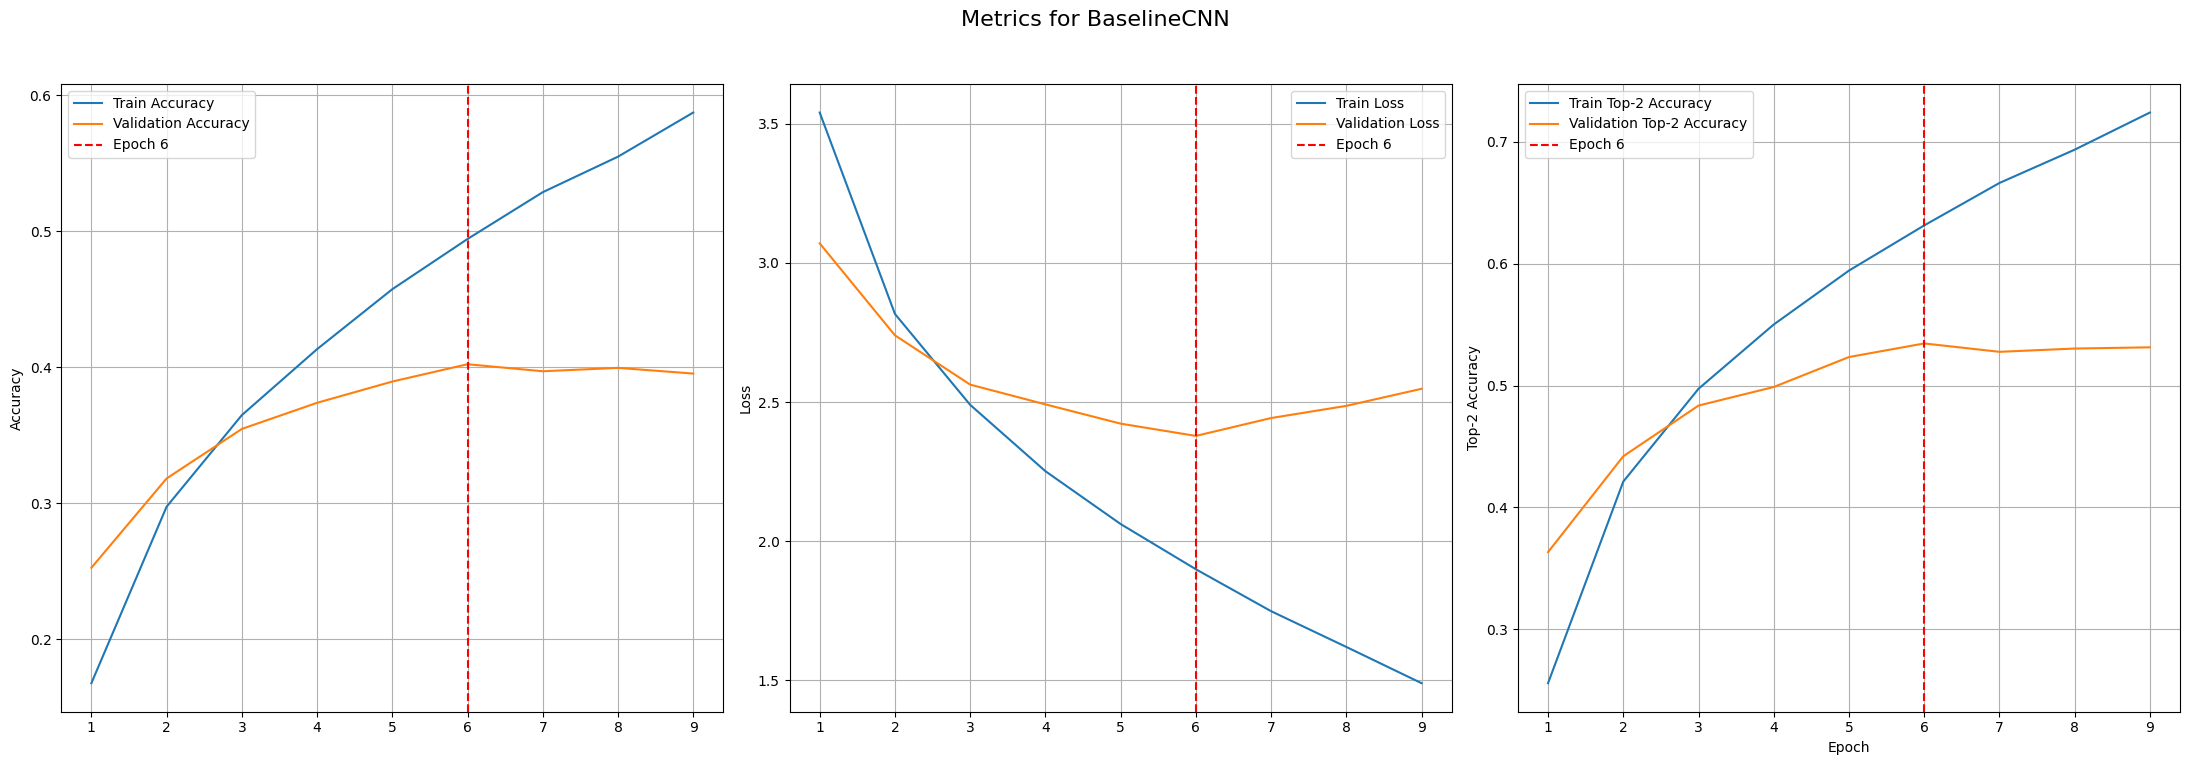

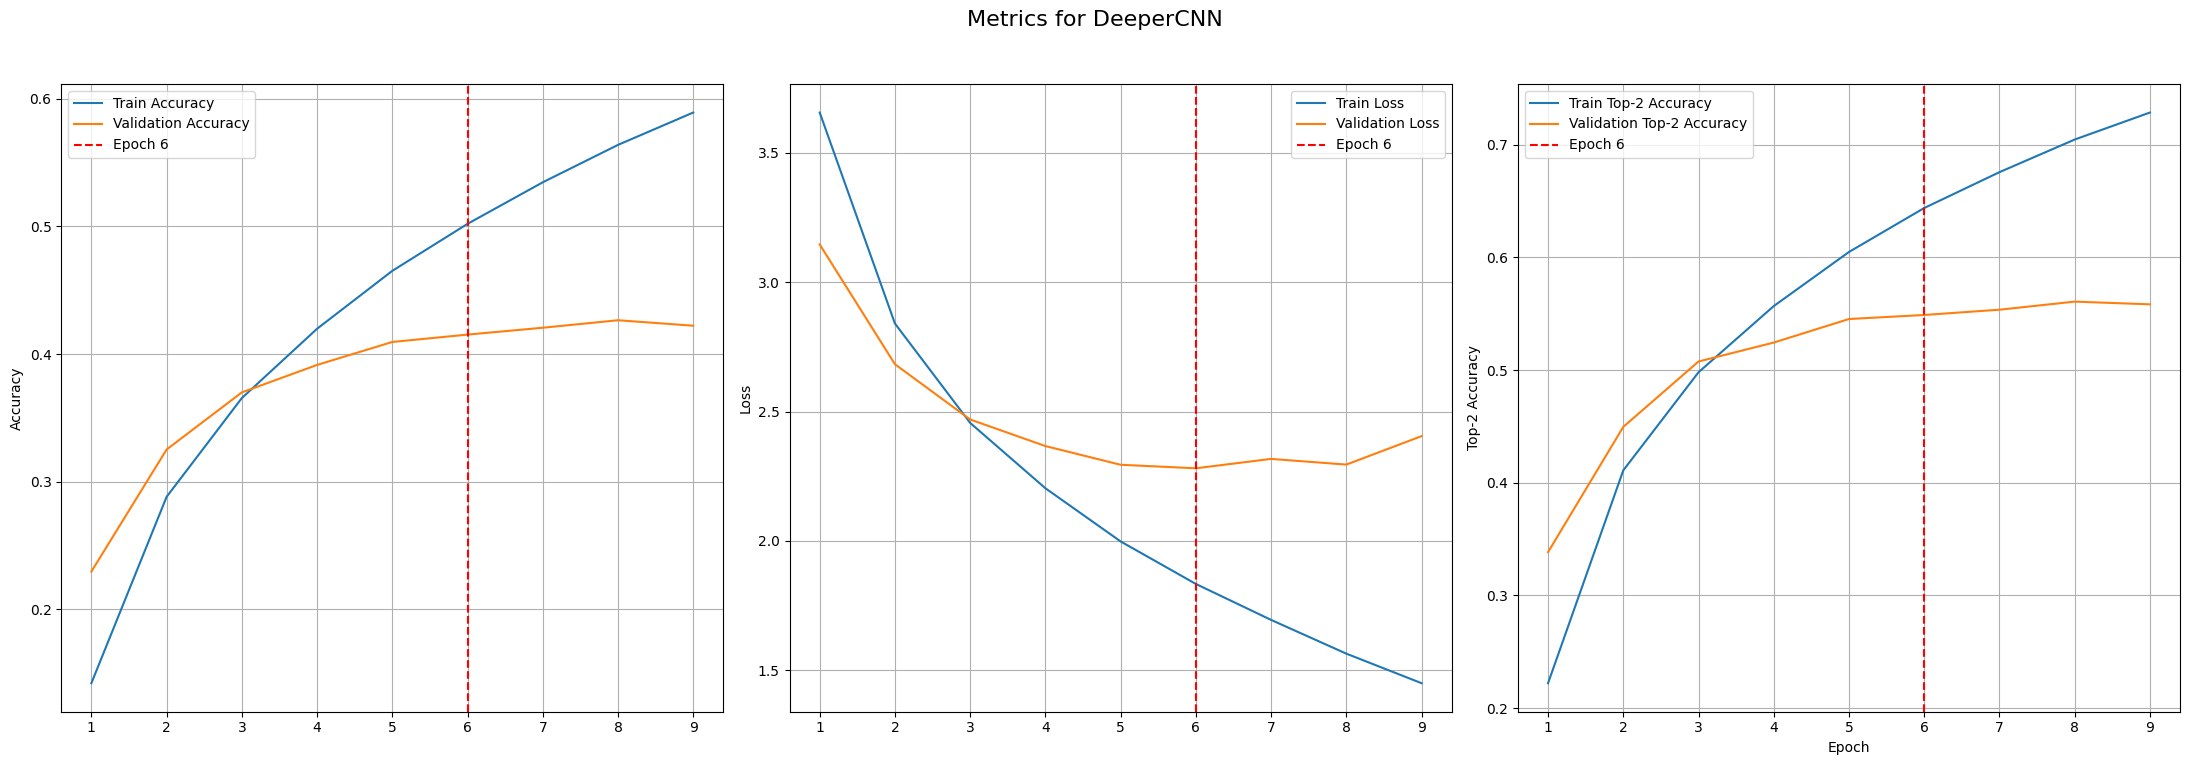

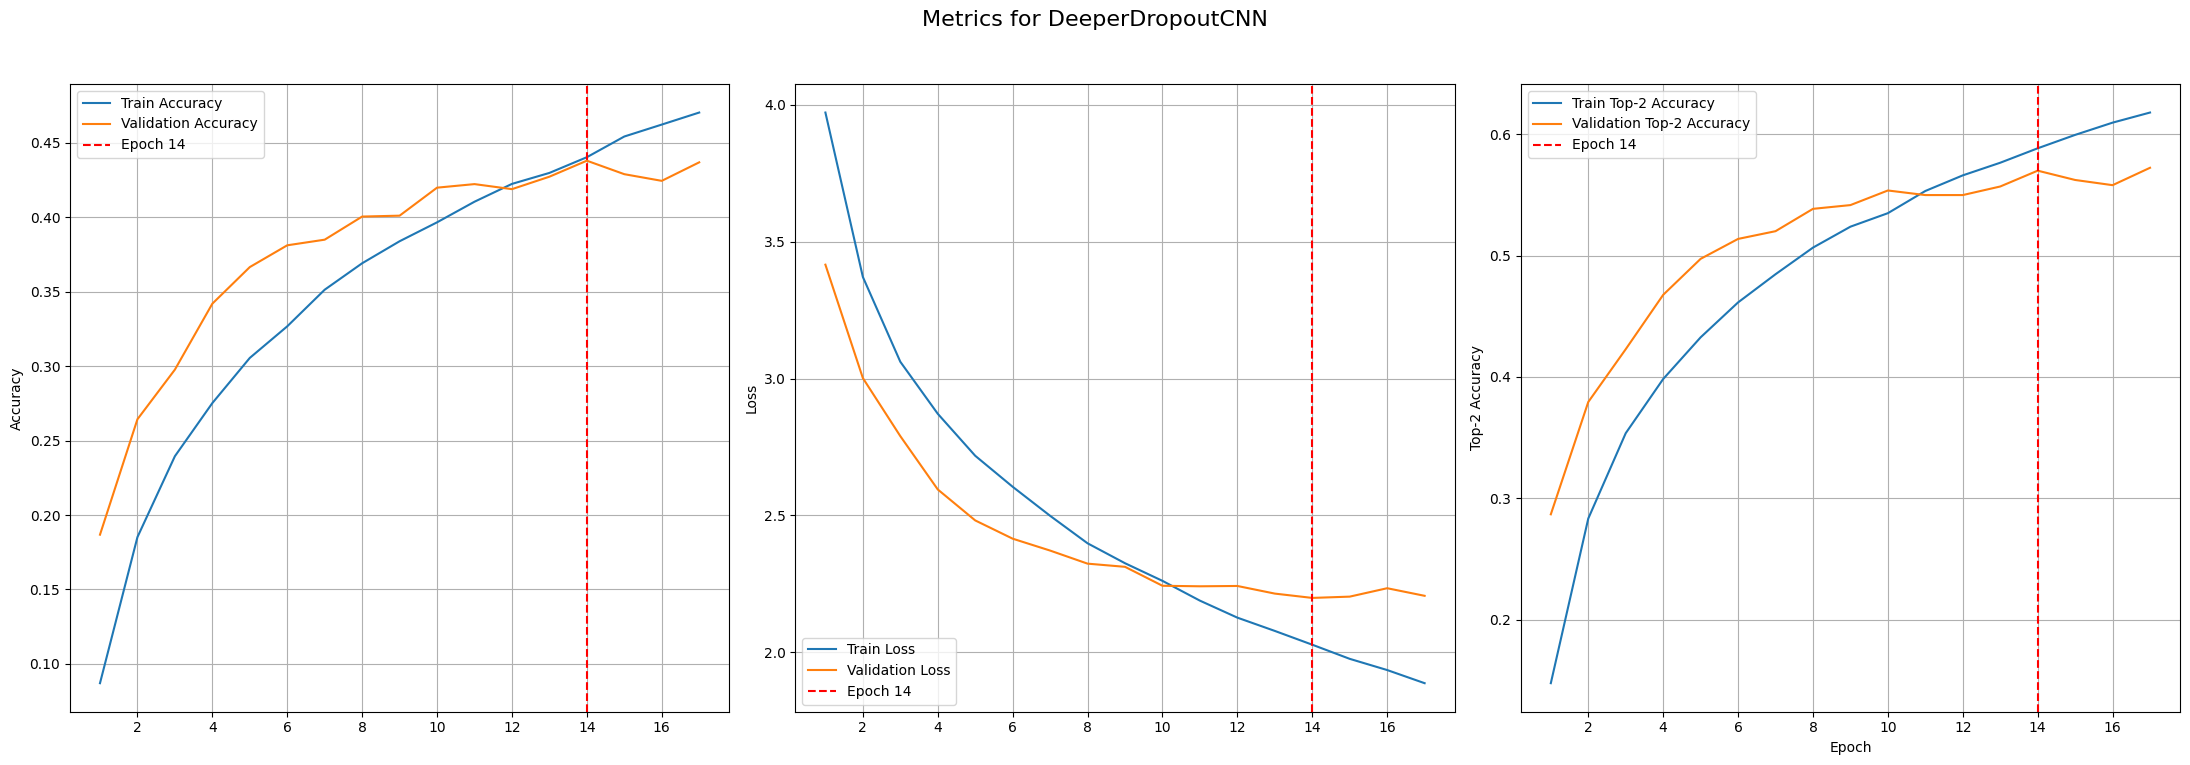

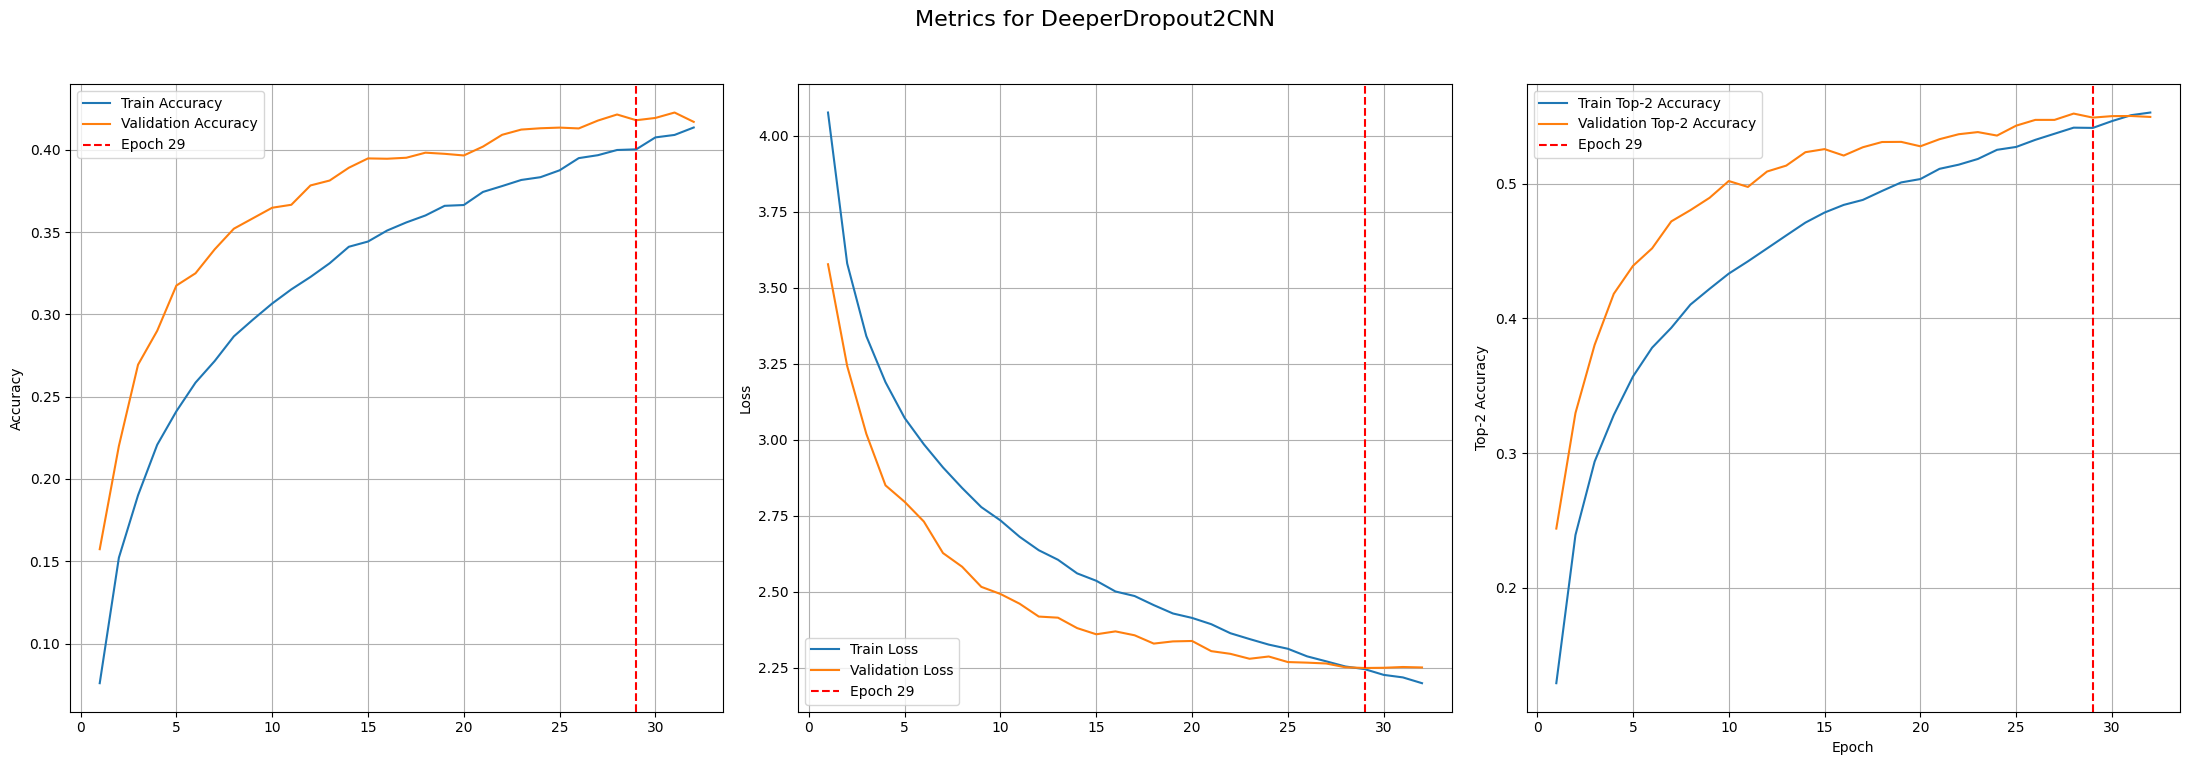

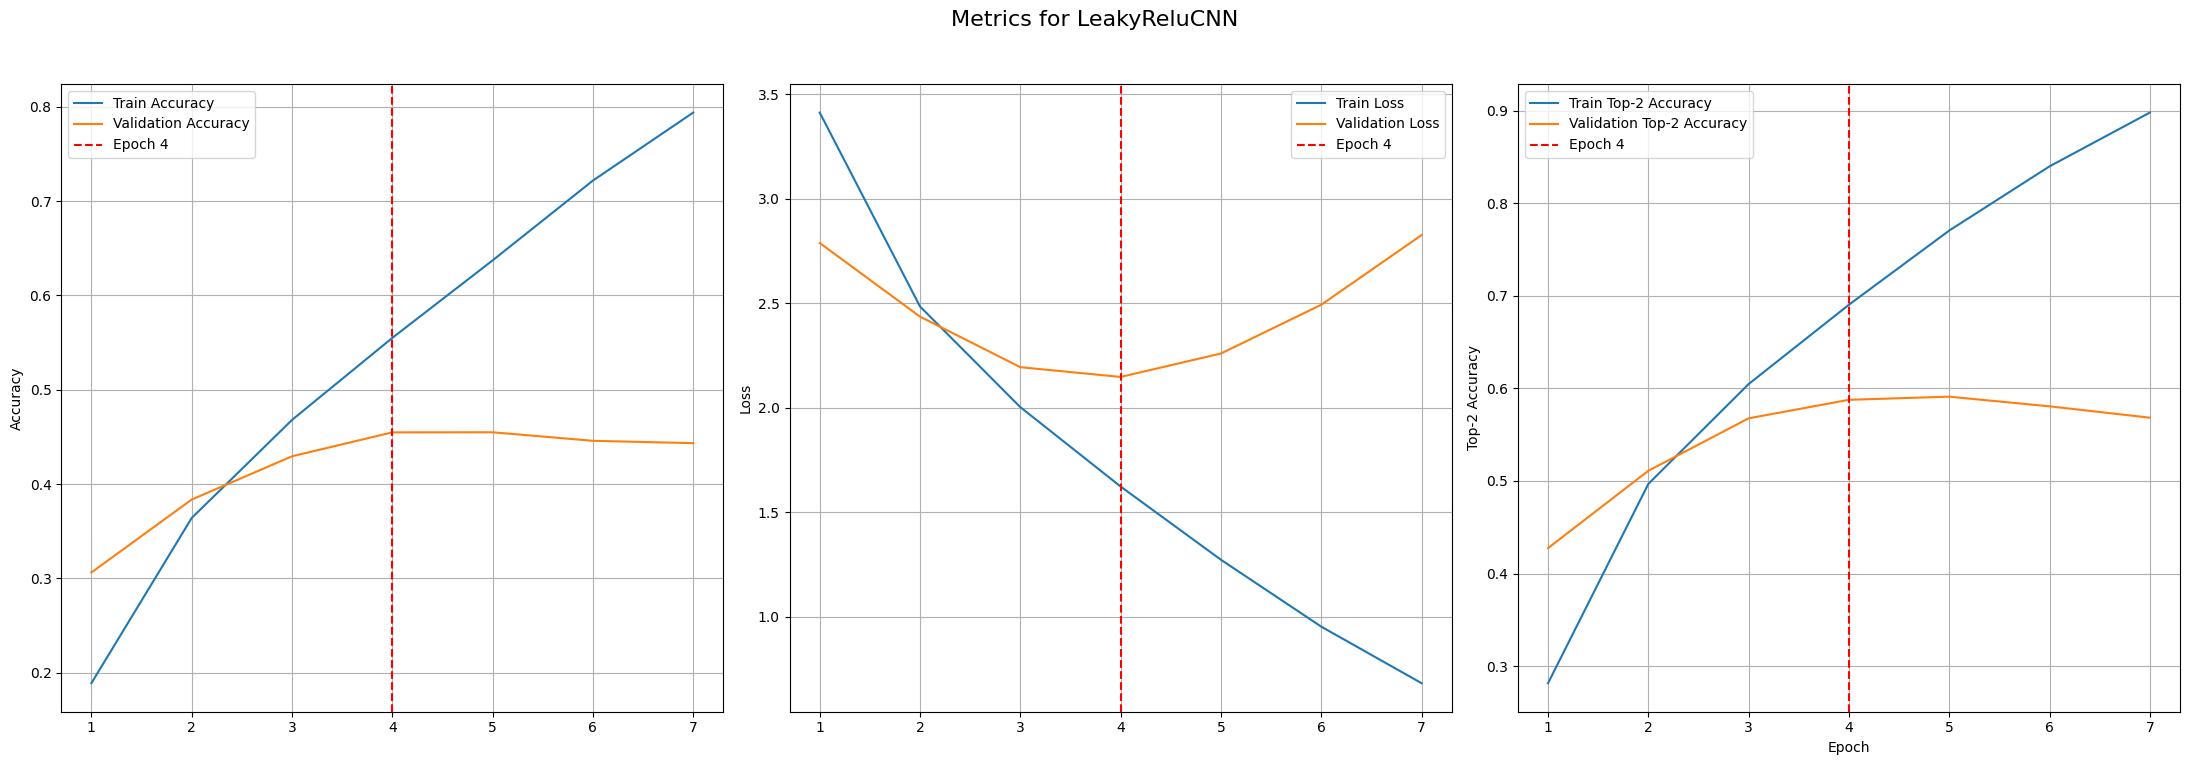

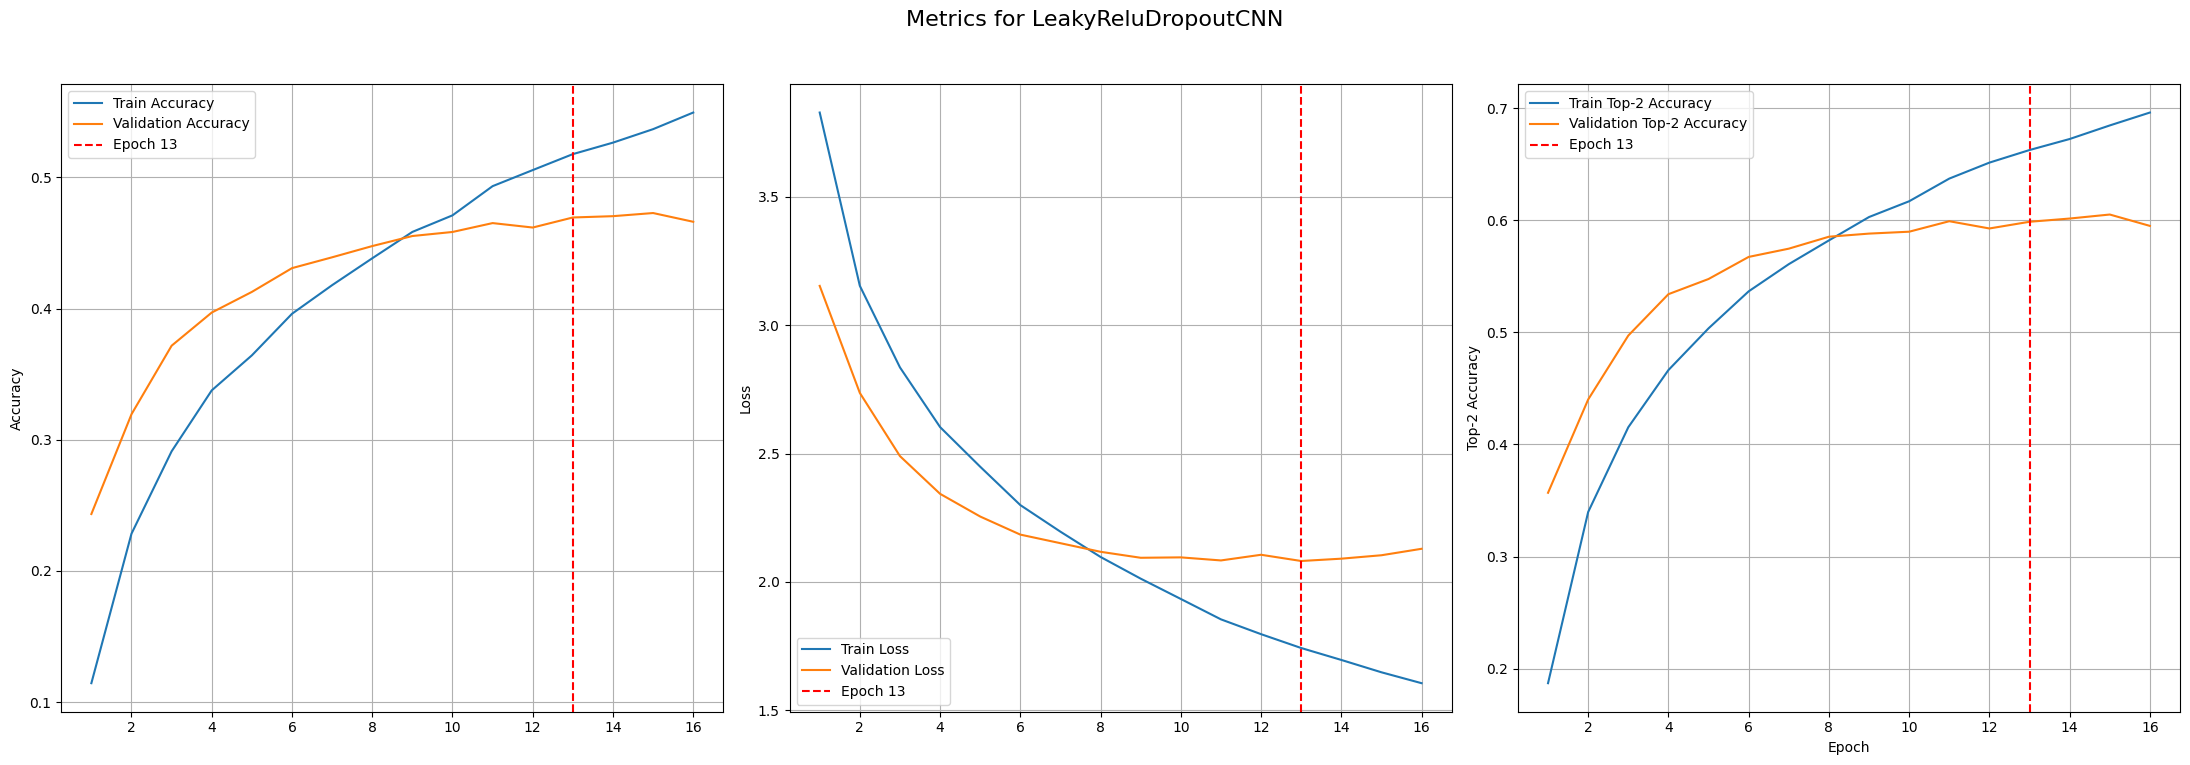

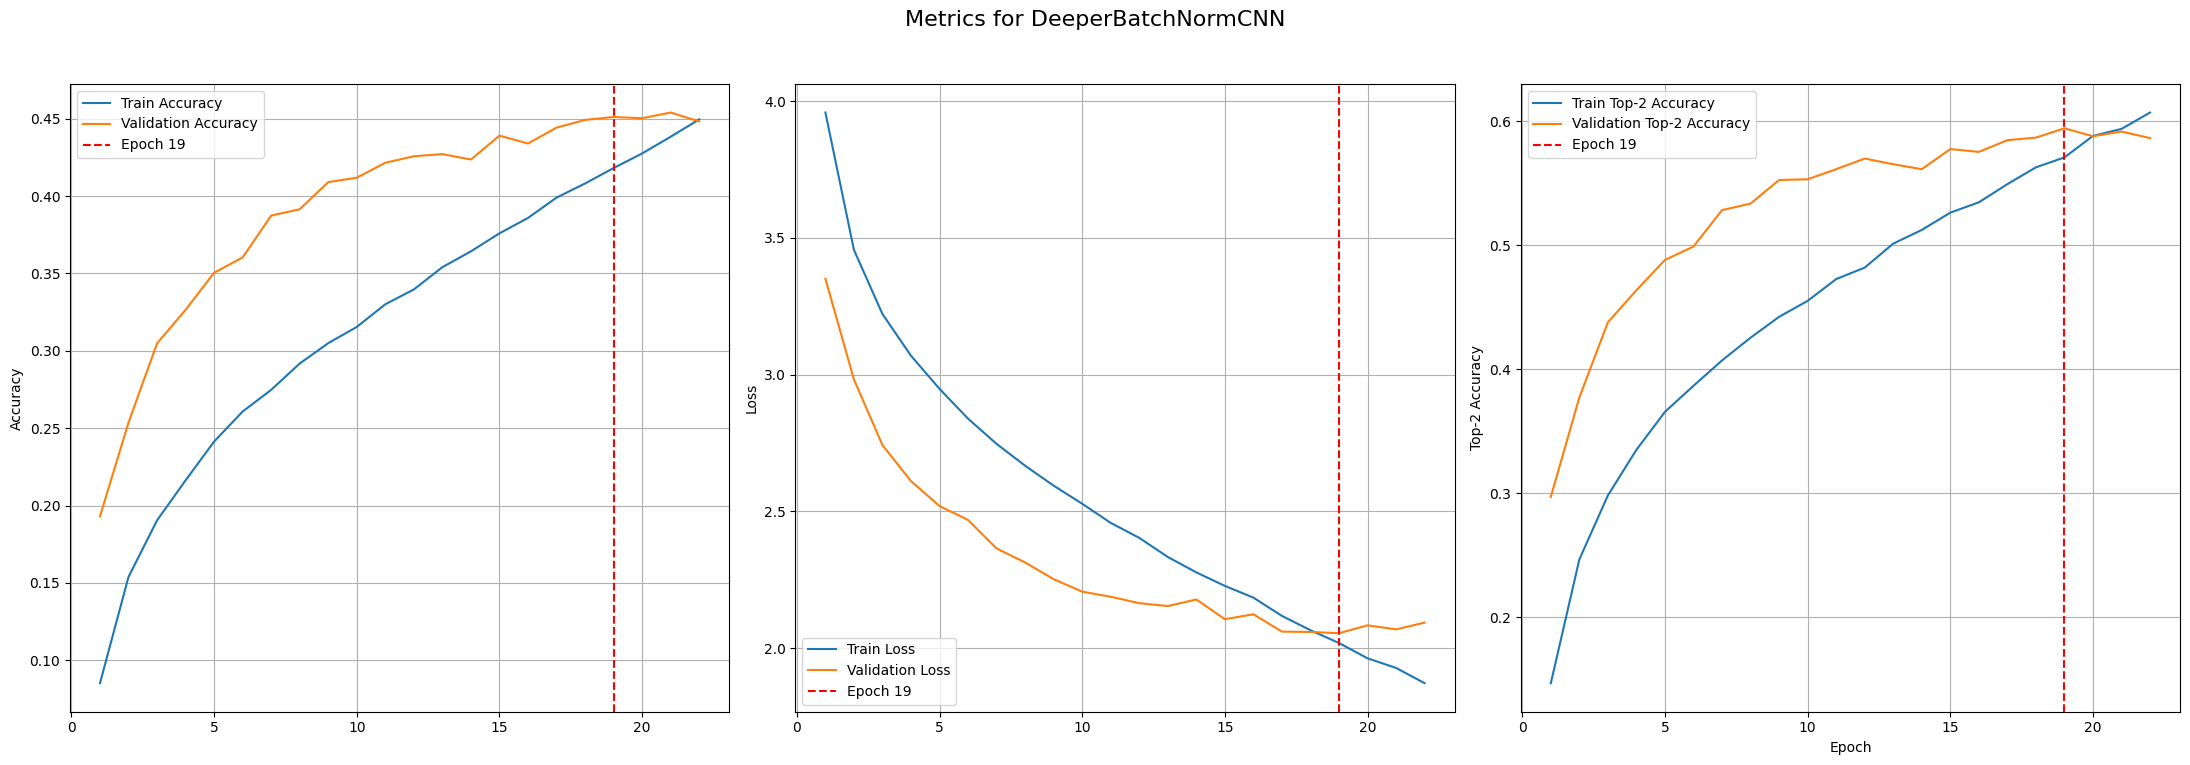

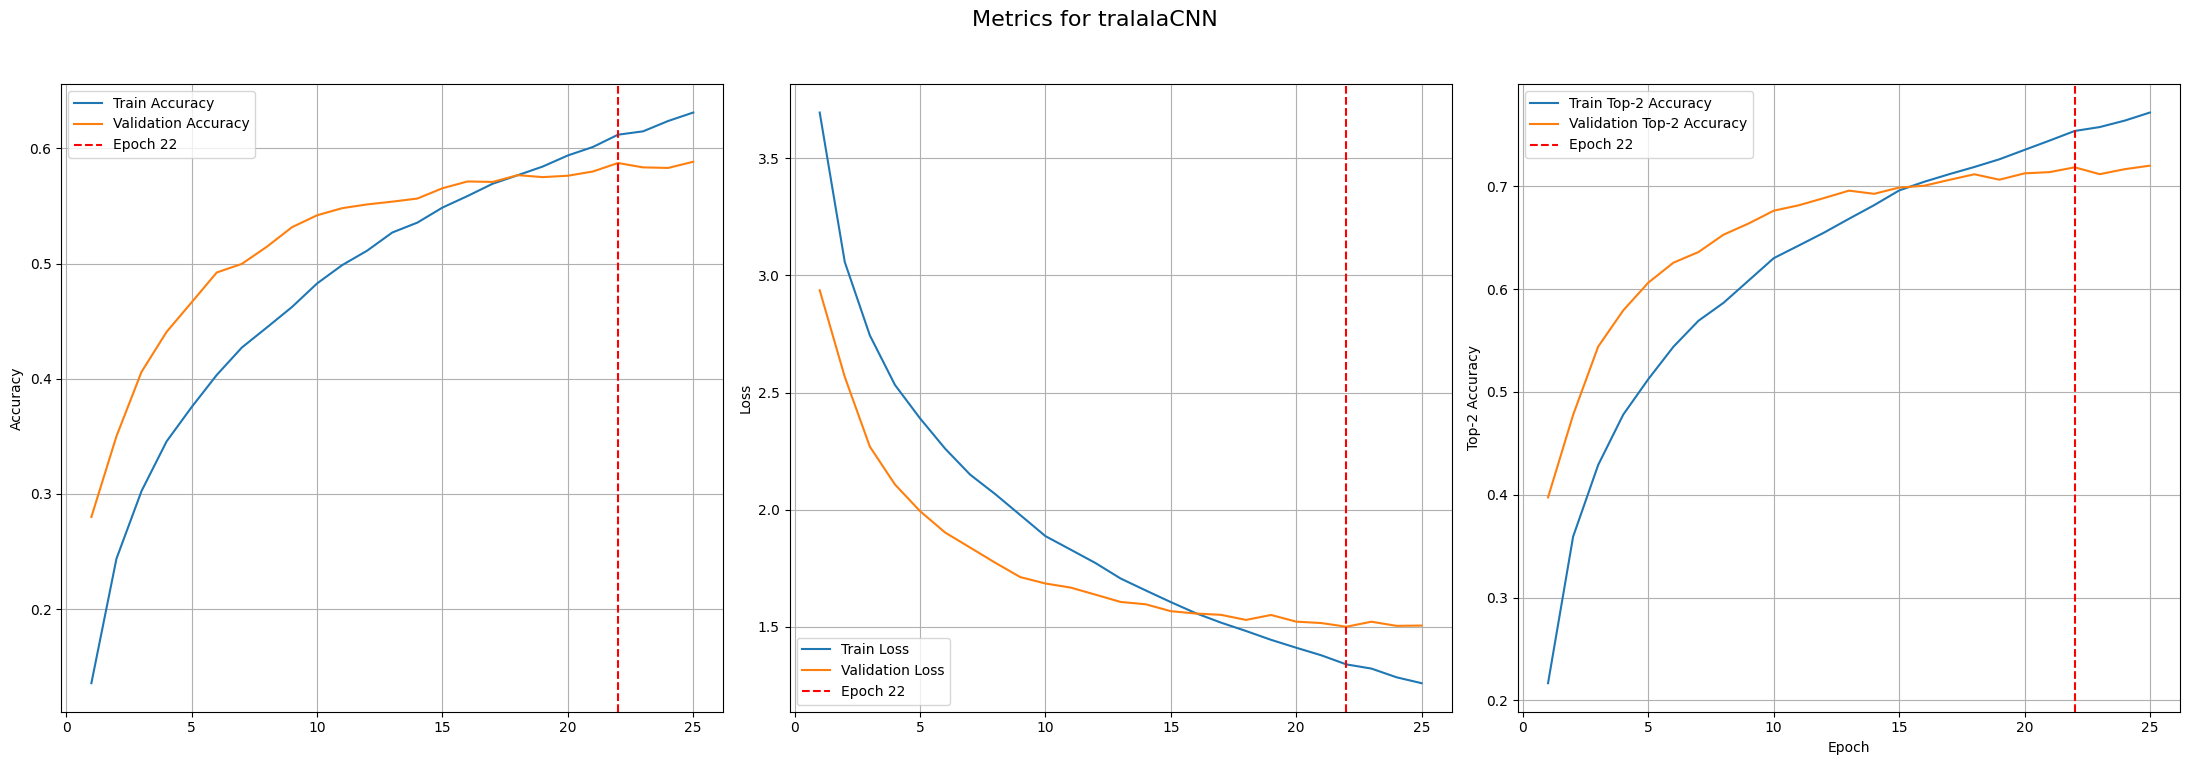

In [47]:
models = df['model'].unique()

for model_name in models:
    model_df = df[df['model'] == model_name]

    line_epoch = model_df['epoch'].iloc[-1]-3

    fig, axs = plt.subplots(1, 3, figsize=(22, 8))
    fig.suptitle(f'Metrics for {model_name}', fontsize=16)

    # 1. Accuracy
    axs[0].plot(model_df['epoch'], model_df['train_accuracy'], label='Train Accuracy')
    axs[0].plot(model_df['epoch'], model_df['val_accuracy'], label='Validation Accuracy')
    axs[0].axvline(x=line_epoch, color='red', linestyle='--', label=f'Epoch {line_epoch}')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Loss
    axs[1].plot(model_df['epoch'], model_df['train_loss'], label='Train Loss')
    axs[1].plot(model_df['epoch'], model_df['val_loss'], label='Validation Loss')
    axs[1].axvline(x=line_epoch, color='red', linestyle='--', label=f'Epoch {line_epoch}')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    axs[1].grid(True)

    # 3. Top-2 Accuracy
    axs[2].plot(model_df['epoch'], model_df['train_top2'], label='Train Top-2 Accuracy')
    axs[2].plot(model_df['epoch'], model_df['val_top2'], label='Validation Top-2 Accuracy')
    axs[2].axvline(x=line_epoch, color='red', linestyle='--', label=f'Epoch {line_epoch}')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Top-2 Accuracy')
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



In [57]:
df = pd.read_csv("results.csv")

summary_df = df.groupby("model").agg({
    "val_accuracy": "max",
    "epoch_time_sec": "sum"
}).reset_index()

# Перейменовуємо колонки для кращого вигляду
summary_df.columns = ["Model", "Best Val_accuracy", "Learning Time (s)"]
summary_df.sort_values("Best Val_accuracy")

,Model,Best Val_accuracy,Learning Time (s)
0,BaselineCNN,0.402269,189.552084
3,DeeperDropout2CNN,0.422572,775.506040
2,DeeperCNN,0.426453,214.434904
4,DeeperDropoutCNN,0.437998,418.787719
1,DeeperBatchNormCNN,0.454021,637.341499
5,LeakyReluCNN,0.454916,162.618952
6,LeakyReluDropoutCNN,0.472830,404.373863
7,tralalaCNN,0.588376,1276.505859


tensor([49], device='cuda:0')
tensor([[5.2684e-07, 1.7103e-03, 1.1245e-03, 2.5120e-04, 3.3558e-03, 1.7675e-03,
         5.9612e-06, 6.5846e-06, 1.4498e-06, 1.1690e-05, 9.4055e-05, 3.0515e-03,
         1.2239e-02, 6.6392e-04, 3.9753e-04, 6.0020e-05, 3.3264e-05, 6.1927e-04,
         3.3522e-04, 3.7967e-04, 1.2116e-04, 2.9956e-04, 2.0979e-04, 1.1360e-02,
         6.3080e-06, 1.9478e-02, 6.7374e-04, 1.8077e-02, 7.2147e-05, 1.2781e-04,
         3.6706e-03, 9.8340e-05, 6.7195e-03, 3.9336e-03, 9.8684e-05, 4.7023e-04,
         4.2318e-04, 8.8349e-04, 1.2573e-05, 4.1759e-06, 4.1977e-04, 6.4514e-06,
         1.5076e-03, 3.5678e-05, 4.3244e-04, 2.8822e-05, 6.7037e-03, 2.4724e-05,
         1.5798e-06, 5.7996e-01, 1.0881e-03, 1.0803e-04, 1.0692e-06, 1.5847e-07,
         4.1393e-05, 2.0273e-03, 4.9952e-06, 4.0284e-07, 1.4593e-04, 2.1177e-05,
         1.0770e-04, 1.3005e-06, 5.0839e-04, 2.9581e-04, 3.5463e-04, 4.2954e-05,
         1.3522e-04, 8.1004e-03, 5.7042e-03, 5.9025e-04, 8.7217e-06, 1.3979e-02

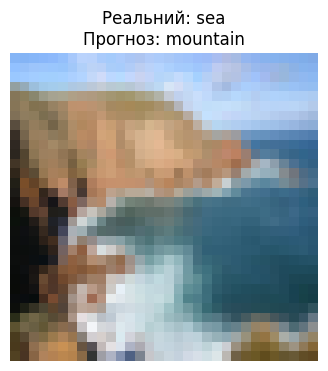

In [50]:
model = tralalaCNN().to("cuda")
model.load_state_dict(torch.load("models/tralalaCNN_19042025_423417_best.pt"))

classes = testset.classes 

idx = random.randint(0, len(testset) - 1)
image, label = testset[idx] 


model.eval()
with torch.no_grad():
    input_tensor = image.unsqueeze(0).to("cuda")  # [1, 3, 32, 32]
    output = model(input_tensor)
    _, preds = output.max(1)
    print(preds)
    # print(output)
    probs = F.softmax(output, dim=1)
    print(probs)
    predicted1 = output.argmax(1).item()
    predicted2 = probs.argmax(1).item()

    if predicted1 != predicted2:
        print("error")

def imshow(img_tensor):
    img_tensor = img_tensor * 0.5 + 0.5  
    np_img = img_tensor.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))  # (C, H, W) -> (H, W, C)

plt.figure(figsize=(4, 4))
imshow(image)
plt.title(f"Реальний: {classes[label]}\nПрогноз: {classes[predicted1]}")
plt.axis('off')
plt.show()

